## Case Study: Modelling

### Instructions
* Use the engineered features and target to train algorithms and develop a model to predict 60 DPD ever in 9 months.
* Evaluate the model using model evaluation techniques
* Submit the output of your best model
* The evaluation function returns the logloss of predicted probabilities for users in OOT dataset with the actual target

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql import types as T

In [2]:
spark = (
    SparkSession.builder.appName('tradeline_features')
    .config('spark.driver.memory', '30g')
    .config('spark.sql.legacy.timeParserPolicy', 'LEGACY')
    .config('spark.sql.codegen.wholeStage', 'false')
    .getOrCreate()
)
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")
spark.conf.set("parquet.enable.dictionary", "false")
spark.conf.set("spark.default.parallelism", 500)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/02 13:32:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/02 13:32:49 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/07/02 13:32:49 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


### Read the OOT data here

```python
trade_var = spark.read.parquet(path + "final_oot_trade.parquet")
inq_var   = spark.read.parquet(path + "final_oot_inq.parquet")
ref       = spark.read.parquet(path + "oot_ref_file.parquet")
```

In [6]:
df = spark.read.parquet("total_final_features3.parquet")
oot_df = spark.read.parquet("oot_features.parquet")

In [8]:
df.select("LATEST_PRODUCT").distinct().orderBy("FIRST_PRODUCT").show(truncate=False)

+--------------+
|LATEST_PRODUCT|
+--------------+
|BL            |
|Other         |
|HL            |
|CC            |
|EL            |
|GL            |
|CE            |
|CV            |
|CD            |
|AL            |
|LAS           |
|OD            |
|PL            |
|TW            |
|LAP           |
+--------------+



In [166]:
oot_df.count()

39962

In [7]:
oot_df.columns

['id',
 'FIRST_PRODUCT',
 'LATEST_PRODUCT',
 'MAX_BUR_VINTAGE',
 'TOTAL_TRADES',
 'TOTAL_TRADES_1_MN',
 'TOTAL_TRADES_3_MN',
 'TOTAL_TRADES_6_MN',
 'TOTAL_TRADES_12_MN',
 'TOTAL_HL_TRADES',
 'TOTAL_GL_TRADES',
 'TOTAL_PL_TRADES',
 'TOTAL_LIVE_PL_TRADES',
 'TOTAL_PL_TRADES_1_MN',
 'TOTAL_PL_TRADES_3_MN',
 'TOTAL_PL_TRADES_6_MN',
 'TOTAL_PL_TRADES_12_MN',
 'TOTAL_CC_TRADES',
 'TOTAL_CC_TRADES_1_MN',
 'TOTAL_CC_TRADES_3_MN',
 'TOTAL_CC_TRADES_6_MN',
 'TOTAL_CC_TRADES_12_MN',
 'TOTAL_SEC_TRADES',
 'TOTAL_UNSEC_TRADES',
 'TOTAL_UNSEC_TRADES_1_MN',
 'TOTAL_UNSEC_TRADES_3_MN',
 'TOTAL_UNSEC_TRADES_6_MN',
 'TOTAL_UNSEC_TRADES_12_MN',
 'TOTAL_INSTALLMENT_TRADES',
 'TOTAL_LIVE_TRADES_M0_M2',
 'TOTAL_LIVE_UNSEC_TRADES_M0_M2',
 'TOTAL_LIVE_INSTALLMENT_TRADES_M0_M2',
 'TOTAL_BALANCE',
 'TOTAL_PL_BALANCE',
 'TOTAL_BL_BALANCE',
 'TOTAL_CD_BALANCE',
 'TOTAL_AL_BALANCE',
 'TOTAL_HL_BALANCE',
 'TOTAL_CC_BALANCE',
 'TOTAL_SANC_AMT',
 'TOTAL_PL_SANC_AMT',
 'TOTAL_BL_SANC_AMT',
 'TOTAL_CD_SANC_AMT',
 'TOTA

In [8]:
df.columns

['id',
 'FIRST_PRODUCT',
 'LATEST_PRODUCT',
 'MAX_BUR_VINTAGE',
 'TOTAL_TRADES',
 'TOTAL_TRADES_1_MN',
 'TOTAL_TRADES_3_MN',
 'TOTAL_TRADES_6_MN',
 'TOTAL_TRADES_12_MN',
 'TOTAL_HL_TRADES',
 'TOTAL_GL_TRADES',
 'TOTAL_PL_TRADES',
 'TOTAL_LIVE_PL_TRADES',
 'TOTAL_PL_TRADES_1_MN',
 'TOTAL_PL_TRADES_3_MN',
 'TOTAL_PL_TRADES_6_MN',
 'TOTAL_PL_TRADES_12_MN',
 'TOTAL_CC_TRADES',
 'TOTAL_CC_TRADES_1_MN',
 'TOTAL_CC_TRADES_3_MN',
 'TOTAL_CC_TRADES_6_MN',
 'TOTAL_CC_TRADES_12_MN',
 'TOTAL_SEC_TRADES',
 'TOTAL_UNSEC_TRADES',
 'TOTAL_UNSEC_TRADES_1_MN',
 'TOTAL_UNSEC_TRADES_3_MN',
 'TOTAL_UNSEC_TRADES_6_MN',
 'TOTAL_UNSEC_TRADES_12_MN',
 'TOTAL_INSTALLMENT_TRADES',
 'TOTAL_LIVE_TRADES_M0_M2',
 'TOTAL_LIVE_UNSEC_TRADES_M0_M2',
 'TOTAL_LIVE_INSTALLMENT_TRADES_M0_M2',
 'TOTAL_BALANCE',
 'TOTAL_PL_BALANCE',
 'TOTAL_BL_BALANCE',
 'TOTAL_CD_BALANCE',
 'TOTAL_AL_BALANCE',
 'TOTAL_HL_BALANCE',
 'TOTAL_CC_BALANCE',
 'TOTAL_SANC_AMT',
 'TOTAL_PL_SANC_AMT',
 'TOTAL_BL_SANC_AMT',
 'TOTAL_CD_SANC_AMT',
 'TOTA

In [9]:
df.select("id").show()

+---+
| id|
+---+
|  7|
| 19|
| 54|
| 65|
|113|
|126|
|130|
|155|
|167|
|188|
|196|
|198|
|202|
|237|
|243|
|270|
|274|
|277|
|278|
|287|
+---+
only showing top 20 rows



In [10]:
df.filter(F.col("id") == 287).show(truncate=False)

26/06/30 21:46:51 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---+-------------+--------------+---------------+------------+-----------------+-----------------+-----------------+------------------+---------------+---------------+---------------+--------------------+--------------------+--------------------+--------------------+---------------------+---------------+--------------------+--------------------+--------------------+---------------------+----------------+------------------+-----------------------+-----------------------+-----------------------+------------------------+------------------------+-----------------------+-----------------------------+-----------------------------------+-------------+----------------+----------------+----------------+----------------+----------------+----------------+--------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+----------------------+----------+----------+-----+-----+-----+-----+-----+-----+---

In [11]:
df.show(5, truncate=False)

+---+-------------+--------------+---------------+------------+-----------------+-----------------+-----------------+------------------+---------------+---------------+---------------+--------------------+--------------------+--------------------+--------------------+---------------------+---------------+--------------------+--------------------+--------------------+---------------------+----------------+------------------+-----------------------+-----------------------+-----------------------+------------------------+------------------------+-----------------------+-----------------------------+-----------------------------------+-------------+----------------+----------------+----------------+----------------+----------------+----------------+--------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+----------------------+------------------+------------------+-----+-----+-----+-----

In [12]:
df.printSchema()

root
 |-- id: long (nullable = true)
 |-- FIRST_PRODUCT: string (nullable = true)
 |-- LATEST_PRODUCT: string (nullable = true)
 |-- MAX_BUR_VINTAGE: double (nullable = true)
 |-- TOTAL_TRADES: long (nullable = true)
 |-- TOTAL_TRADES_1_MN: long (nullable = true)
 |-- TOTAL_TRADES_3_MN: long (nullable = true)
 |-- TOTAL_TRADES_6_MN: long (nullable = true)
 |-- TOTAL_TRADES_12_MN: long (nullable = true)
 |-- TOTAL_HL_TRADES: long (nullable = true)
 |-- TOTAL_GL_TRADES: long (nullable = true)
 |-- TOTAL_PL_TRADES: long (nullable = true)
 |-- TOTAL_LIVE_PL_TRADES: long (nullable = true)
 |-- TOTAL_PL_TRADES_1_MN: long (nullable = true)
 |-- TOTAL_PL_TRADES_3_MN: long (nullable = true)
 |-- TOTAL_PL_TRADES_6_MN: long (nullable = true)
 |-- TOTAL_PL_TRADES_12_MN: long (nullable = true)
 |-- TOTAL_CC_TRADES: long (nullable = true)
 |-- TOTAL_CC_TRADES_1_MN: long (nullable = true)
 |-- TOTAL_CC_TRADES_3_MN: long (nullable = true)
 |-- TOTAL_CC_TRADES_6_MN: long (nullable = true)
 |-- TOTAL_CC

In [13]:
len(df.columns)

236

In [14]:
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show()

+---+-------------+--------------+---------------+------------+-----------------+-----------------+-----------------+------------------+---------------+---------------+---------------+--------------------+--------------------+--------------------+--------------------+---------------------+---------------+--------------------+--------------------+--------------------+---------------------+----------------+------------------+-----------------------+-----------------------+-----------------------+------------------------+------------------------+-----------------------+-----------------------------+-----------------------------------+-------------+----------------+----------------+----------------+----------------+----------------+----------------+--------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+----------------------+----------+----------+-----+-----+-----+-----+-----+-----+---

In [15]:
print("Number of rows :", df.count())
print("Number of columns :", len(df.columns))

df.printSchema()

Number of rows : 90414
Number of columns : 236
root
 |-- id: long (nullable = true)
 |-- FIRST_PRODUCT: string (nullable = true)
 |-- LATEST_PRODUCT: string (nullable = true)
 |-- MAX_BUR_VINTAGE: double (nullable = true)
 |-- TOTAL_TRADES: long (nullable = true)
 |-- TOTAL_TRADES_1_MN: long (nullable = true)
 |-- TOTAL_TRADES_3_MN: long (nullable = true)
 |-- TOTAL_TRADES_6_MN: long (nullable = true)
 |-- TOTAL_TRADES_12_MN: long (nullable = true)
 |-- TOTAL_HL_TRADES: long (nullable = true)
 |-- TOTAL_GL_TRADES: long (nullable = true)
 |-- TOTAL_PL_TRADES: long (nullable = true)
 |-- TOTAL_LIVE_PL_TRADES: long (nullable = true)
 |-- TOTAL_PL_TRADES_1_MN: long (nullable = true)
 |-- TOTAL_PL_TRADES_3_MN: long (nullable = true)
 |-- TOTAL_PL_TRADES_6_MN: long (nullable = true)
 |-- TOTAL_PL_TRADES_12_MN: long (nullable = true)
 |-- TOTAL_CC_TRADES: long (nullable = true)
 |-- TOTAL_CC_TRADES_1_MN: long (nullable = true)
 |-- TOTAL_CC_TRADES_3_MN: long (nullable = true)
 |-- TOTAL_CC_TR

In [16]:
df.groupBy("id").count().filter(F.col("count") > 1).show()

+---+-----+
| id|count|
+---+-----+
+---+-----+



In [17]:
df.filter(F.col("user_ever60_9m").isNull()).count()

0

In [18]:
df.filter(F.col("id").isNull()).count()

0

In [19]:
df.groupBy("user_ever60_9m").count().show()

+--------------+-----+
|user_ever60_9m|count|
+--------------+-----+
|             1|17632|
|             0|72782|
+--------------+-----+



In [20]:
# Bad Rate

In [21]:
df.agg(
        (
            F.sum(F.col("user_ever60_9m")) /
            F.count("*") * 100
        ).alias("Bad_Rate")
    ).show()

+-----------------+
|         Bad_Rate|
+-----------------+
|19.50140464972239|
+-----------------+



In [22]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

In [23]:
print(f"Train Rows : {train_df.count()}")
print(f"Test Rows  : {test_df.count()}")

print(f"Train % : {train_df.count() / df.count() * 100:.2f}%")
print(f"Test %  : {test_df.count() / df.count() * 100:.2f}%")

Train Rows : 72311


Test Rows  : 18103


Train % : 79.98%


Test %  : 20.02%


In [24]:
def bad_rate(data, target_col="user_ever60_9m"):

    total = data.count()

    bad = data.filter(F.col(target_col) == 1).count()

    good = total - bad

    print(f"Rows     : {total}")
    print(f"Bad      : {bad}")
    print(f"Good     : {good}")
    print(f"Bad Rate : {bad/total*100:.2f}%")

In [25]:
print("Overall")
bad_rate(df)

print("\nTrain")
bad_rate(train_df)

print("\nTest")
bad_rate(test_df)

Overall
Rows     : 90414
Bad      : 17632
Good     : 72782
Bad Rate : 19.50%

Train


Rows     : 72311
Bad      : 14092
Good     : 58219
Bad Rate : 19.49%

Test


Rows     : 18103
Bad      : 3540
Good     : 14563
Bad Rate : 19.55%


In [26]:
common_ids = (
    train_df.select("id")
    .intersect(test_df.select("id"))
)

print("Common IDs :", common_ids.count())

Common IDs : 0


In [27]:
feature_cols = [c for c in train_df.columns if c not in ["id", "user_ever60_9m"]]

In [28]:
len(feature_cols)

234

In [29]:
# numeric_cols = []

# categorical_cols = []

# for col_name, dtype in train_df.dtypes:

#     if col_name in ["id", "user_ever60_9m"]:
#         continue

#     if dtype in ["string"]:
#         categorical_cols.append(col_name)
#     else:
#         numeric_cols.append(col_name)

In [30]:
# print("Numeric Features :", len(numeric_cols))
# print("Categorical Features :", len(categorical_cols))

# print(categorical_cols)

In [31]:
import pandas as pd
import numpy as np

target_col = "user_ever60_9m"
ignore_cols = ["id", target_col]

feature_cols = [c for c in train_df.columns if c not in ignore_cols]

pdf = train_df.select(feature_cols + [target_col]).toPandas()

def calc_iv(df, col, target_col, bins=10):
    x = df[col]
    y = df[target_col]

    if x.dtype.kind in "biufc" and x.nunique(dropna=True) > 20:
        try:
            b = pd.qcut(x, q=bins, duplicates="drop")
        except:
            b = x
    else:
        # string / low-cardinality numeric -> treat as category
        b = x.astype("object")

    temp = pd.DataFrame({"bin": b, "target": y})
    temp["bin"] = temp["bin"].astype("object").fillna("Missing")

    g = temp.groupby("bin")["target"].agg(
        event=lambda s: (s == 1).sum(),
        non_event=lambda s: (s == 0).sum()
    ).reset_index()

    total_event = (y == 1).sum()
    total_non_event = (y == 0).sum()

    g["dist_event"] = g["event"] / total_event
    g["dist_non_event"] = g["non_event"] / total_non_event

    g["dist_event"] = g["dist_event"].replace(0, 1e-6)
    g["dist_non_event"] = g["dist_non_event"].replace(0, 1e-6)

    g["woe"] = np.log(g["dist_event"] / g["dist_non_event"])
    g["iv"] = (g["dist_event"] - g["dist_non_event"]) * g["woe"]

    return g["iv"].sum()

rows = []
for col in feature_cols:
    try:
        iv = calc_iv(pdf, col, target_col)
        rows.append((col, iv))
    except:
        rows.append((col, np.nan))

iv_df = pd.DataFrame(rows, columns=["feature", "IV"]).dropna()
iv_df = iv_df.sort_values("IV", ascending=False).reset_index(drop=True)

/tmp/ipykernel_43847/4116424233.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp["bin"] = temp["bin"].astype("object").fillna("Missing")
/tmp/ipykernel_43847/4116424233.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp["bin"] = temp["bin"].astype("object").fillna("Missing")
/tmp/ipykernel_43847/4116424233.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('fut

In [32]:
iv_df

,feature,IV
0,H1203,0.257419
1,H0103,0.246826
2,H4303,0.231048
3,H4203,0.227452
4,H3203,0.226213
...,...,...
229,H2536,0.000000
230,H2436,0.000000
231,H2236,0.000000
232,H1536,0.000000


In [33]:
print(len(feature_cols))

234


In [34]:
print(len(rows))

234


In [35]:
# iv_df.to_csv("iv_table.csv", index=False)

In [36]:
# the IV distribution
iv_df.describe()

,IV
count,234.000000
mean,0.041796
std,0.059567
min,0.000000
25%,0.004259
50%,0.018449
75%,0.042362
max,0.257419


In [37]:
iv_df[iv_df["feature"].isin(["FIRST_PRODUCT", "LATEST_PRODUCT"])]

,feature,IV
74,LATEST_PRODUCT,0.035396
84,FIRST_PRODUCT,0.029126


In [38]:
# So, No evidence of target leakage as max	0.257419

In [39]:
# Number of features at different thresholds

thresholds = [0, 0.001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.10]

for t in thresholds:
    count = (iv_df["IV"] >= t).sum()
    print(f"IV >= {t}: {count} features")

IV >= 0: 234 features
IV >= 0.001: 206 features
IV >= 0.005: 171 features
IV >= 0.01: 152 features
IV >= 0.02: 111 features
IV >= 0.03: 81 features
IV >= 0.04: 64 features
IV >= 0.05: 46 features
IV >= 0.1: 32 features


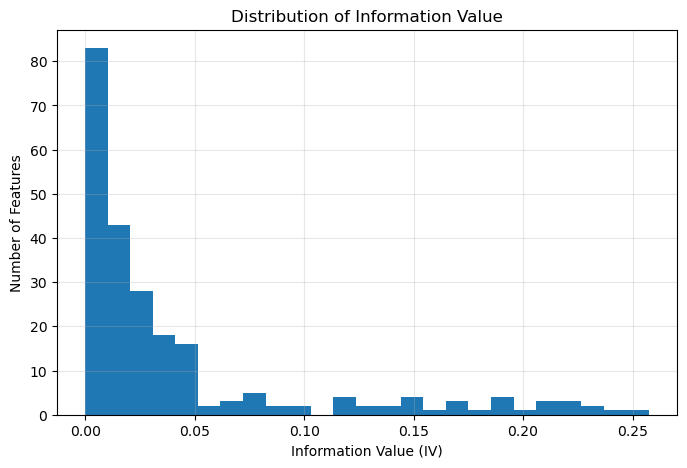

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(iv_df["IV"], bins=25)
plt.xlabel("Information Value (IV)")
plt.ylabel("Number of Features")
plt.title("Distribution of Information Value")
plt.grid(alpha=0.3)
plt.show()

In [41]:
threshold = 0.03

selected_iv = iv_df[iv_df["IV"] >= threshold].copy()
selected_features = selected_iv["feature"].tolist()

In [42]:
print("Threshold:", threshold)
print("Selected features:", len(selected_features))
print(selected_iv.head(10))

Threshold: 0.03
Selected features: 81
  feature        IV
0   H1203  0.257419
1   H0103  0.246826
2   H4303  0.231048
3   H4203  0.227452
4   H3203  0.226213
5   H4103  0.225449
6   H1212  0.224187
7   H0203  0.212086
8   H4212  0.207768
9   H0112  0.206965


In [43]:
filtered_df = df.select(selected_features + [target_col])

In [44]:
filtered_pdf = pdf[selected_features + [target_col]].copy()

In [45]:
# selected_iv.to_csv("selected_iv_threshold_003.csv", index=False)

In [46]:
# Correlation

In [47]:
# numeric columns only
num_cols = filtered_pdf[selected_features].select_dtypes(include="number").columns

corr = filtered_pdf[num_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

print("Columns to drop:", len(to_drop))
print(to_drop[:20])

final_features = [c for c in selected_features if c not in to_drop]
final_df = filtered_pdf[final_features + [target_col]].copy()

Columns to drop: 44
['H4103', 'H0203', 'H1403', 'H0212', 'H4312', 'H0303', 'H1412', 'H0312', 'H3403', 'H1503', 'H0403', 'H3412', 'H0412', 'H1512', 'H3503', 'H4136', 'H3512', 'H0503', 'H0512', 'H3236']


In [48]:
print("Final features:", len(final_features))

Final features: 37


In [49]:
print(final_df.dtypes)

H1203                                       int32
H0103                                       int32
H4303                                       int32
H4203                                       int32
H3203                                       int32
H1212                                       int32
H4212                                       int32
H0112                                       int32
H3212                                       int32
H4112                                       int32
DPD_RECOVERY_RATE                         float64
H4236                                       int32
H4336                                       int32
H0236                                       int32
MICRO_UTIL                                float64
MEDIAN_DAYS_SO_UNSECURED_IN_LAST_36_MN      int32
TOTAL_WO_SF_36O_TRADES                      int64
MACRO_UTIL                                float64
MEDIAN_DAYS_SO_IN_LAST_36_MN                int32
TOTAL_WO_SF_TRADES                          int64


In [50]:
# Create Spark DataFrames with Final Features

In [51]:
train_final = train_df.select(
    ["id"] + final_features + [target_col]
)

test_final = test_df.select(
    ["id"] + final_features + [target_col]
)


In [52]:
categorical_cols = [
    c for c in final_features
    if dict(train_final.dtypes)[c] == "string"
]

print(categorical_cols)

['LATEST_PRODUCT']


In [53]:
cat_col = "LATEST_PRODUCT"
num_cols = [c for c in final_features if c != cat_col]

In [54]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

In [55]:
indexer = StringIndexer(
    inputCol=cat_col,
    outputCol=cat_col + "_idx",
    handleInvalid="keep"
)

In [56]:
encoder = OneHotEncoder(
    inputCols=[cat_col + "_idx"],
    outputCols=[cat_col + "_ohe"],
    handleInvalid="keep"
)

In [57]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[indexer, encoder])

In [58]:
# Fit ONLY on Training Data
ohe_model = pipeline.fit(train_final)

In [59]:
train_final = ohe_model.transform(train_final)
test_final = ohe_model.transform(test_final)

In [60]:
train_final.select(
    "LATEST_PRODUCT",
    "LATEST_PRODUCT_idx",
    "LATEST_PRODUCT_ohe"
).show(10, truncate=False)

+--------------+------------------+------------------+
|LATEST_PRODUCT|LATEST_PRODUCT_idx|LATEST_PRODUCT_ohe|
+--------------+------------------+------------------+
|PL            |0.0               |(16,[0],[1.0])    |
|PL            |0.0               |(16,[0],[1.0])    |
|PL            |0.0               |(16,[0],[1.0])    |
|PL            |0.0               |(16,[0],[1.0])    |
|CD            |1.0               |(16,[1],[1.0])    |
|GL            |2.0               |(16,[2],[1.0])    |
|CD            |1.0               |(16,[1],[1.0])    |
|PL            |0.0               |(16,[0],[1.0])    |
|PL            |0.0               |(16,[0],[1.0])    |
|PL            |0.0               |(16,[0],[1.0])    |
+--------------+------------------+------------------+
only showing top 10 rows



In [61]:
# remove the original categorical column and replace it with the encoded column.
assembler_features = [
    c for c in final_features
    if c not in categorical_cols
]

assembler_features.extend(
    [f"{col}_ohe" for col in categorical_cols]
)

print(assembler_features)
print("Total Features:", len(assembler_features))

['H1203', 'H0103', 'H4303', 'H4203', 'H3203', 'H1212', 'H4212', 'H0112', 'H3212', 'H4112', 'DPD_RECOVERY_RATE', 'H4236', 'H4336', 'H0236', 'MICRO_UTIL', 'MEDIAN_DAYS_SO_UNSECURED_IN_LAST_36_MN', 'TOTAL_WO_SF_36O_TRADES', 'MACRO_UTIL', 'MEDIAN_DAYS_SO_IN_LAST_36_MN', 'TOTAL_WO_SF_TRADES', 'MEDIAN_DAYS_SO_PL_IN_LAST_36_MN', 'MEDIAN_DAYS_SO_UNSECURED_IN_LAST_12_MN', 'NUM_CONSEC_MONTHS_ZERO_DPD', 'TOTAL_CC_TRADES', 'TOTAL_PL_TRADES_6_MN', 'DPD_SLOPE_6M', 'TOTAL_CC_SANC_AMT', 'MEDIAN_DAYS_SO_UNSECURED_IN_LAST_6_MN', 'MEDIAN_DAYS_SO_PL_IN_LAST_12_MN', 'AVG_PL_BUR_VINTAGE', 'TOTAL_PL_SANC_AMT', 'MEDIAN_DAYS_SO_PL_IN_LAST_6_MN', 'G403', 'AVG_CC_BUR_VINTAGE', 'G7112', 'G412', 'LATEST_PRODUCT_ohe']
Total Features: 37


In [62]:
# VectorAssembler

In [63]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=assembler_features,
    outputCol="features",
    handleInvalid="keep"
)

In [64]:
train_final = assembler.transform(train_final)
test_final = assembler.transform(test_final)

In [65]:
train_final.select("features").show(1, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                                                                        |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|(52,[10,14,15,17,18,20,21,22,24,25,27,28,29,30,31,32,33,34,35,36],[-1.0,-1.0,19.0,-1.0,19.0,19.0,19.0,14.0,11.0,-1.0,19.0,19.0,8.789677418,180209.0,19.0,5.0,-1.0,1.0,17.0,1.0])|
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
only showing top 1 row



In [66]:
train_model = train_final.select(
    "id",
    "features",
    F.col(target_col).alias("label")
)

test_model = test_final.select(
    "id",
    "features",
    F.col(target_col).alias("label")
)

In [67]:
from xgboost.spark import SparkXGBClassifier

In [68]:
xgb = SparkXGBClassifier(

    features_col="features",
    label_col="label",

    eval_metric="logloss",

    max_depth=4,
    learning_rate=0.03,
    n_estimators=400,

    subsample=0.6,
    colsample_bytree=0.6,

    scale_pos_weight =2,
    reg_alpha = 1,
    min_child_weight = 3,
    gamma=0.5,
    

    seed=42
)

In [69]:
xgb_model = xgb.fit(train_model)

2026-06-30 21:48:59,893 INFO XGBoost-PySpark: _fit Running xgboost-2.1.4 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.6, 'device': 'cpu', 'eval_metric': 'logloss', 'gamma': 0.5, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 3, 'reg_alpha': 1, 'scale_pos_weight': 2, 'subsample': 0.6, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 400}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-06-30 21:49:03,640 INFO XGBoost-PySpark: _train_booster Training on CPUs 1]
[21:49:04] Task 0 got rank 0
2026-06-30 21:49:09,341 INFO XGBoost-PySpark: _fit Finished xgboost training!   


In [70]:
train_model.printSchema()

root
 |-- id: long (nullable = true)
 |-- features: vector (nullable = true)
 |-- label: integer (nullable = true)



In [71]:
train_pred = xgb_model.transform(train_model)

In [72]:
# Predict on test

In [73]:
test_pred = xgb_model.transform(test_model)

In [74]:
# xgb_model.save("xgb_baseline_model")

In [75]:
# train_model.coalesce(1).write \
#     .mode("overwrite") \
#     .parquet("train_model.parquet")

# test_model.coalesce(1).write \
#     .mode("overwrite") \
#     .parquet("test_model.parquet")

In [76]:
# train_model = spark.read.parquet("train_model.parquet")
# test_model = spark.read.parquet("test_model.parquet")

In [77]:
test_pred.select(
    "label",
    "prediction",
    "probability"
).show(5, truncate=False)

2026-06-30 21:49:12,348 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1    |1.0       |[0.09923231601715088,0.9007676839828491]|
|0    |0.0       |[0.7580649852752686,0.24193498492240906]|
|0    |0.0       |[0.7283527851104736,0.27164724469184875]|
|0    |0.0       |[0.7615589499473572,0.23844105005264282]|
|1    |0.0       |[0.6950087547302246,0.304991215467453]  |
+-----+----------+----------------------------------------+
only showing top 5 rows



# ROC-AUC

In [78]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="probability",
    metricName="areaUnderROC"
)

train_auc = evaluator.evaluate(train_pred)
test_auc = evaluator.evaluate(test_pred)

print("Train AUC :", train_auc)
print("Test AUC  :", test_auc)

2026-06-30 21:49:15,652 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:49:18,139 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


Train AUC : 0.733133509335733
Test AUC  : 0.7106452444493067


2026-06-30 21:49:19,962 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:49:22,294 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


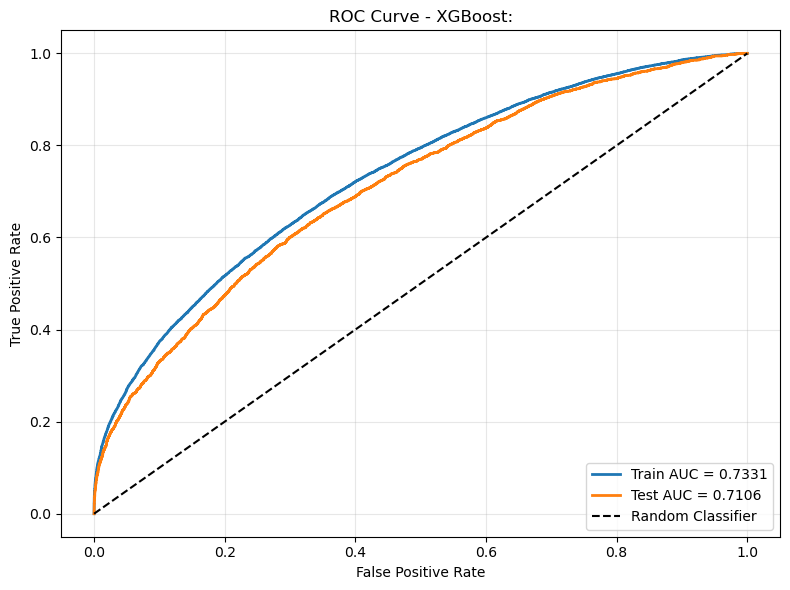

In [79]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from pyspark.ml.functions import vector_to_array

# -------------------------------
# Train ROC
# -------------------------------
train_pdf = train_pred.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

fpr_train, tpr_train, _ = roc_curve(
    train_pdf["label"],
    train_pdf["score"]
)

auc_train = auc(fpr_train, tpr_train)

# -------------------------------
# Test ROC
# -------------------------------
test_pdf = test_pred.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

fpr_test, tpr_test, _ = roc_curve(
    test_pdf["label"],
    test_pdf["score"]
)

auc_test = auc(fpr_test, tpr_test)

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(8,6))

plt.plot(
    fpr_train,
    tpr_train,
    label=f"Train AUC = {auc_train:.4f}",
    linewidth=2
)

plt.plot(
    fpr_test,
    tpr_test,
    label=f"Test AUC = {auc_test:.4f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    "k--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost:")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("xgboost_roc_curve.png", dpi=300)

plt.show()

# Logloss

In [80]:
from sklearn.metrics import log_loss

In [81]:
# take positive-class probability
from pyspark.ml.functions import vector_to_array

pred_pdf = test_pred.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

y_true = pred_pdf["label"].values
y_score = pred_pdf["score"].values

ll = log_loss(y_true, y_score)
print("Test LogLoss:", ll)

2026-06-30 21:49:24,436 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


Test LogLoss: 0.4771926147676284


In [82]:
train_pdf = train_pred.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

train_ll = log_loss(
    train_pdf["label"],
    train_pdf["score"]
)

print("Train LogLoss:", train_ll)

2026-06-30 21:49:26,001 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


Train LogLoss: 0.46455825136164625


# Gini

In [83]:
train_gini = 2 * train_auc - 1
test_gini = 2 * test_auc - 1

print("Train Gini:", train_gini)
print("Test Gini :", test_gini)

Train Gini: 0.4662670186714659
Test Gini : 0.4212904888986133


# Precision, Recall, F1, Accuracy

In [84]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [85]:
# Precision
precision_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

# Recall
recall_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

# F1 Score
f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

# Accuracy
accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)


# ==========================
# Train Metrics
# ==========================

train_precision = precision_eval.evaluate(train_pred)
train_recall = recall_eval.evaluate(train_pred)
train_f1 = f1_eval.evaluate(train_pred)
train_accuracy = accuracy_eval.evaluate(train_pred)

# ==========================
# Test Metrics
# ==========================

test_precision = precision_eval.evaluate(test_pred)
test_recall = recall_eval.evaluate(test_pred)
test_f1 = f1_eval.evaluate(test_pred)
test_accuracy = accuracy_eval.evaluate(test_pred)

# ==========================
# Print Results
# ==========================

print("=" * 60)
print("TRAIN METRICS")
print("=" * 60)
print(f"Accuracy : {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall   : {train_recall:.4f}")
print(f"F1 Score : {train_f1:.4f}")

print("\n" + "=" * 60)
print("TEST METRICS")
print("=" * 60)
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

2026-06-30 21:49:28,266 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:49:30,194 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:49:32,382 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:49:34,550 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:49:36,491 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:49:37,905 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:49:39,512 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:49:40,930 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


TRAIN METRICS
Accuracy : 0.8166
Precision: 0.7887
Recall   : 0.8166
F1 Score : 0.7911

TEST METRICS
Accuracy : 0.8067
Precision: 0.7752
Recall   : 0.8067
F1 Score : 0.7807


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve
from pyspark.ml.functions import vector_to_array

# Convert Spark prediction to Pandas
pred_pdf = (
    train_pred
    .select(
        "label",
        vector_to_array("probability")[1].alias("score")
    )
    .toPandas()
)

pred_pdf["label"] = pred_pdf["label"].astype(int)
pred_pdf["score"] = pred_pdf["score"].astype(float)

# -----------------------------
# KS Statistic (continuous)
# -----------------------------
fpr, tpr, thresholds = roc_curve(
    pred_pdf["label"],
    pred_pdf["score"]
)

ks_values = tpr - fpr
ks_idx = np.argmax(ks_values)

ks_stat = ks_values[ks_idx]
ks_threshold = thresholds[ks_idx]

print(f"Train KS Statistic : {ks_stat*100:.2f}%")
print(f"Train KS Threshold : {ks_threshold:.6f}")

# -----------------------------
# Create Deciles
# -----------------------------
pred_pdf = pred_pdf.sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

pred_pdf["decile"] = pd.qcut(
    pred_pdf.index,
    10,
    labels=range(1,11)
)

# -----------------------------
# KS Table
# -----------------------------
ks_table = pred_pdf.groupby("decile").agg(
    Min_Prob=("score","min"),
    Max_Prob=("score","max"),
    Events=("label","sum"),
    Total=("label","count")
).reset_index()

ks_table["Non_Events"] = ks_table["Total"] - ks_table["Events"]

ks_table["Event_Rate"] = (
    ks_table["Events"] /
    ks_table["Events"].sum() * 100
)

ks_table["Non_Event_Rate"] = (
    ks_table["Non_Events"] /
    ks_table["Non_Events"].sum() * 100
)

ks_table["Cum_Event_Rate"] = ks_table["Event_Rate"].cumsum()

ks_table["Cum_Non_Event_Rate"] = (
    ks_table["Non_Event_Rate"].cumsum()
)

ks_table["KS"] = (
    ks_table["Cum_Event_Rate"] -
    ks_table["Cum_Non_Event_Rate"]
).abs()

# Round for display
cols = [
    "Min_Prob",
    "Max_Prob",
    "Event_Rate",
    "Non_Event_Rate",
    "Cum_Event_Rate",
    "Cum_Non_Event_Rate",
    "KS"
]

ks_table[cols] = ks_table[cols].round(2)

print(
    "\nTrain KS Statistic from Decile Table:",
    round(ks_table["KS"].max(), 2)
)

display(ks_table)

ks_table.to_csv("train_ks_table.csv", index=False)

# # -----------------------------
# # KS Curve
# # -----------------------------
# plt.figure(figsize=(8,5))

# plt.plot(
#     ks_table["decile"],
#     ks_table["Cum_Event_Rate"],
#     marker="o",
#     linewidth=2,
#     label="Cumulative Event Rate"
# )

# plt.plot(
#     ks_table["decile"],
#     ks_table["Cum_Non_Event_Rate"],
#     marker="o",
#     linewidth=2,
#     label="Cumulative Non-Event Rate"
# )

# plt.title(
#     f"Train KS Curve (KS = {ks_table['KS'].max():.2f})"
# )

# plt.xlabel("Decile")
# plt.ylabel("Cumulative Percentage")

# plt.xticks(range(1,11))

# plt.grid(alpha=0.3)

# plt.legend()

# plt.tight_layout()

# plt.savefig("train_ks_curve.png", dpi=200)

# plt.show()

2026-06-30 21:49:42,309 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


Train KS Statistic : 32.83%
Train KS Threshold : 0.319031

Train KS Statistic from Decile Table: 32.65


/tmp/ipykernel_43847/3964196771.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ks_table = pred_pdf.groupby("decile").agg(


,decile,Min_Prob,Max_Prob,Events,Total,Non_Events,Event_Rate,Non_Event_Rate,Cum_Event_Rate,Cum_Non_Event_Rate,KS
0,1,0.50,0.98,3993,7232,3239,28.34,5.56,28.34,5.56,22.77
1,2,0.40,0.50,2166,7231,5065,15.37,8.70,43.71,14.26,29.44
2,3,0.35,0.40,1723,7231,5508,12.23,9.46,55.93,23.72,32.21
3,4,0.31,0.35,1459,7231,5772,10.35,9.91,66.29,33.64,32.65
4,5,0.28,0.31,1245,7231,5986,8.83,10.28,75.12,43.92,31.20
5,6,0.25,0.28,1059,7231,6172,7.51,10.60,82.64,54.52,28.11
6,7,0.22,0.25,924,7231,6307,6.56,10.83,89.19,65.35,23.84
7,8,0.18,0.22,732,7231,6499,5.19,11.16,94.39,76.52,17.87
8,9,0.14,0.18,511,7231,6720,3.63,11.54,98.01,88.06,9.95
9,10,0.04,0.14,280,7231,6951,1.99,11.94,100.00,100.00,0.00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve
from pyspark.ml.functions import vector_to_array

# Convert Spark prediction to Pandas
pred_pdf = (
    test_pred
    .select(
        "label",
        vector_to_array("probability")[1].alias("score")
    )
    .toPandas()
)

pred_pdf["label"] = pred_pdf["label"].astype(int)
pred_pdf["score"] = pred_pdf["score"].astype(float)

# -----------------------------
# KS Statistic (continuous)
# -----------------------------
fpr, tpr, thresholds = roc_curve(
    pred_pdf["label"],
    pred_pdf["score"]
)

ks_values = tpr - fpr
ks_idx = np.argmax(ks_values)

ks_stat = ks_values[ks_idx]
ks_threshold = thresholds[ks_idx]

print(f"KS Statistic : {ks_stat*100:.2f}%")
print(f"KS Threshold : {ks_threshold:.6f}")

# -----------------------------
# Create Deciles
# -----------------------------
pred_pdf = pred_pdf.sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

pred_pdf["decile"] = pd.qcut(
    pred_pdf.index,
    10,
    labels=range(1,11)
)

# -----------------------------
# KS Table
# -----------------------------
ks_table = pred_pdf.groupby("decile").agg(
    Min_Prob=("score","min"),
    Max_Prob=("score","max"),
    Events=("label","sum"),
    Total=("label","count")
).reset_index()

ks_table["Non_Events"] = ks_table["Total"] - ks_table["Events"]

ks_table["Event_Rate"] = ks_table["Events"] / ks_table["Events"].sum() * 100
ks_table["Non_Event_Rate"] = ks_table["Non_Events"] / ks_table["Non_Events"].sum() * 100

ks_table["Cum_Event_Rate"] = ks_table["Event_Rate"].cumsum()
ks_table["Cum_Non_Event_Rate"] = ks_table["Non_Event_Rate"].cumsum()

ks_table["KS"] = (
    ks_table["Cum_Event_Rate"] -
    ks_table["Cum_Non_Event_Rate"]
).abs()

# Round for display
cols = [
    "Min_Prob","Max_Prob",
    "Event_Rate","Non_Event_Rate",
    "Cum_Event_Rate","Cum_Non_Event_Rate",
    "KS"
]

ks_table[cols] = ks_table[cols].round(2)

print("\nKS Statistic from Decile Table:",
      round(ks_table["KS"].max(),2))

display(ks_table)

ks_table.to_csv("ks_table.csv", index=False)

# -----------------------------
# KS Curve
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(
    ks_table["decile"],
    ks_table["Cum_Event_Rate"],
    marker="o",
    linewidth=2,
    label="Cumulative Event Rate"
)

plt.plot(
    ks_table["decile"],
    ks_table["Cum_Non_Event_Rate"],
    marker="o",
    linewidth=2,
    label="Cumulative Non-Event Rate"
)

plt.title(
    "KS Curve XGBoost"
)

plt.xlabel("Decile")
plt.ylabel("Cumulative Percentage")

plt.xticks(range(1,11))

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig("ks_curve.png", dpi=200)

plt.show()

# XGBoost for all Featurs

In [89]:
all_features = [
    c for c in train_df.columns
    if c not in ["id", target_col]
]

train_all = train_df.select(
    ["id"] + all_features + [target_col]
)

test_all = test_df.select(
    ["id"] + all_features + [target_col]
)

In [90]:
categorical_cols_all = [
    c for c in all_features
    if dict(train_all.dtypes)[c] == "string"
]

print(categorical_cols_all)

['FIRST_PRODUCT', 'LATEST_PRODUCT']


In [91]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in categorical_cols_all
]

encoders = [
    OneHotEncoder(
        inputCol=f"{c}_idx",
        outputCol=f"{c}_ohe"
    )
    for c in categorical_cols_all
]

In [92]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=indexers + encoders)

pipeline_model = pipeline.fit(train_all)

train_all = pipeline_model.transform(train_all)
test_all = pipeline_model.transform(test_all)

In [93]:
from pyspark.ml.feature import VectorAssembler

assembler_features_all = [
    c for c in all_features
    if c not in categorical_cols_all
]

assembler_features_all.extend(
    [f"{c}_ohe" for c in categorical_cols_all]
)

assembler_all = VectorAssembler(
    inputCols=assembler_features_all,
    outputCol="features",
    handleInvalid="keep"
)

train_all = assembler_all.transform(train_all)
test_all = assembler_all.transform(test_all)

In [94]:
train_model_all = train_all.select(
    "id",
    "features",
    F.col(target_col).alias("label")
)

test_model_all = test_all.select(
    "id",
    "features",
    F.col(target_col).alias("label")
)

In [95]:
from xgboost.spark import SparkXGBClassifier

xgb_all = SparkXGBClassifier(
    features_col="features",
    label_col="label",

    eval_metric="logloss",

    max_depth=4,
    learning_rate=0.03,
    n_estimators=400,

    subsample=0.6,
    colsample_bytree=0.6,

    scale_pos_weight =2,
    reg_alpha = 1,
    min_child_weight = 3,
    gamma=0.5,
    

    seed=42
)

xgb_all_model = xgb_all.fit(train_model_all)

2026-06-30 21:50:24,648 INFO XGBoost-PySpark: _fit Running xgboost-2.1.4 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.6, 'device': 'cpu', 'eval_metric': 'logloss', 'gamma': 0.5, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 3, 'reg_alpha': 1, 'scale_pos_weight': 2, 'subsample': 0.6, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 400}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-06-30 21:50:27,994 INFO XGBoost-PySpark: _train_booster Training on CPUs 9]
[21:50:29] Task 0 got rank 0                                        (0 + 1) / 1]
2026-06-30 21:50:45,800 INFO XGBoost-PySpark: _fit Finished xgboost training!   


In [96]:
train_pred_all = xgb_all_model.transform(train_model_all)
test_pred_all = xgb_all_model.transform(test_model_all)

In [97]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="probability",
    metricName="areaUnderROC"
)

train_auc_all = evaluator.evaluate(train_pred_all)
test_auc_all = evaluator.evaluate(test_pred_all)

print("="*60)
print("XGBoost (All Features) ROC-AUC")
print("="*60)
print(f"Train AUC : {train_auc_all:.4f}")
print(f"Test AUC  : {test_auc_all:.4f}")

2026-06-30 21:50:46,620 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:50:50,930 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


XGBoost (All Features) ROC-AUC
Train AUC : 0.7602
Test AUC  : 0.7252


In [98]:
from sklearn.metrics import log_loss
from pyspark.ml.functions import vector_to_array

# Train
train_pdf = train_pred_all.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

train_logloss_all = log_loss(
    train_pdf["label"],
    train_pdf["score"]
)

# Test
test_pdf = test_pred_all.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

test_logloss_all = log_loss(
    test_pdf["label"],
    test_pdf["score"]
)

print("="*60)
print("XGBoost (All Features) LogLoss")
print("="*60)
print(f"Train LogLoss : {train_logloss_all:.4f}")
print(f"Test LogLoss  : {test_logloss_all:.4f}")

2026-06-30 21:50:53,329 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:50:57,676 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


XGBoost (All Features) LogLoss
Train LogLoss : 0.4503
Test LogLoss  : 0.4682


In [99]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

precision_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

# Train
train_accuracy_all = accuracy_eval.evaluate(train_pred_all)
train_precision_all = precision_eval.evaluate(train_pred_all)
train_recall_all = recall_eval.evaluate(train_pred_all)
train_f1_all = f1_eval.evaluate(train_pred_all)

# Test
test_accuracy_all = accuracy_eval.evaluate(test_pred_all)
test_precision_all = precision_eval.evaluate(test_pred_all)
test_recall_all = recall_eval.evaluate(test_pred_all)
test_f1_all = f1_eval.evaluate(test_pred_all)

print("="*60)
print("Train Metrics")
print("="*60)
print(f"Accuracy : {train_accuracy_all:.4f}")
print(f"Precision: {train_precision_all:.4f}")
print(f"Recall   : {train_recall_all:.4f}")
print(f"F1 Score : {train_f1_all:.4f}")

print("\n" + "="*60)
print("Test Metrics")
print("="*60)
print(f"Accuracy : {test_accuracy_all:.4f}")
print(f"Precision: {test_precision_all:.4f}")
print(f"Recall   : {test_recall_all:.4f}")
print(f"F1 Score : {test_f1_all:.4f}")

2026-06-30 21:50:59,650 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:51:03,759 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:51:07,587 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:51:11,633 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:51:15,371 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:51:17,157 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:51:19,242 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-06-30 21:51:21,313 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


Train Metrics
Accuracy : 0.8246
Precision: 0.8002
Recall   : 0.8246
F1 Score : 0.7999

Test Metrics
Accuracy : 0.8107
Precision: 0.7812
Recall   : 0.8107
F1 Score : 0.7856


In [100]:
import numpy as np
from sklearn.metrics import roc_curve
from pyspark.ml.functions import vector_to_array

train_pdf = train_pred_all.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

fpr, tpr, thresholds = roc_curve(
    train_pdf["label"],
    train_pdf["score"]
)

train_ks = np.max(tpr - fpr)
train_threshold = thresholds[np.argmax(tpr - fpr)]

print("="*60)
print("XGBoost (All Features) Train KS")
print("="*60)
print(f"KS Statistic : {train_ks:.4f}")
print(f"KS (%)       : {train_ks*100:.2f}")
print(f"Threshold    : {train_threshold:.6f}")

2026-06-30 21:51:23,533 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


XGBoost (All Features) Train KS
KS Statistic : 0.3734
KS (%)       : 37.34
Threshold    : 0.348432


In [101]:
test_pdf = test_pred_all.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

fpr, tpr, thresholds = roc_curve(
    test_pdf["label"],
    test_pdf["score"]
)

test_ks = np.max(tpr - fpr)
test_threshold = thresholds[np.argmax(tpr - fpr)]

print("="*60)
print("XGBoost (All Features) Test KS")
print("="*60)
print(f"KS Statistic : {test_ks:.4f}")
print(f"KS (%)       : {test_ks*100:.2f}")
print(f"Threshold    : {test_threshold:.6f}")

2026-06-30 21:51:27,603 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


XGBoost (All Features) Test KS
KS Statistic : 0.3178
KS (%)       : 31.78
Threshold    : 0.288051


# Decision Tree

In [102]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator

dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    seed=42
)

paramGrid = (
    ParamGridBuilder()
    .addGrid(dt.maxDepth, [3, 5, 7, 10])
    .addGrid(dt.minInstancesPerNode, [1, 5, 10])
    .addGrid(dt.impurity, ["gini", "entropy"])
    .build()
)

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

cv = CrossValidator(
    estimator=dt,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=5,
    seed=42
)

dt_cv_model = cv.fit(train_model)

best_dt = dt_cv_model.bestModel

In [103]:
print("Best Decision Tree")

print("Depth :", best_dt.getMaxDepth())
print("Impurity :", best_dt.getImpurity())
print("Min Instances :", best_dt.getMinInstancesPerNode())

Best Decision Tree
Depth : 10
Impurity : entropy
Min Instances : 1


In [104]:
train_pred_dt = best_dt.transform(train_model)
test_pred_dt = best_dt.transform(test_model)

In [105]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="probability",
    metricName="areaUnderROC"
)

train_auc_dt = evaluator.evaluate(train_pred_dt)
test_auc_dt = evaluator.evaluate(test_pred_dt)

print("="*60)
print("Decision Tree ROC-AUC")
print("="*60)
print(f"Train AUC : {train_auc_dt:.4f}")
print(f"Test AUC  : {test_auc_dt:.4f}")

Decision Tree ROC-AUC
Train AUC : 0.7172
Test AUC  : 0.6671


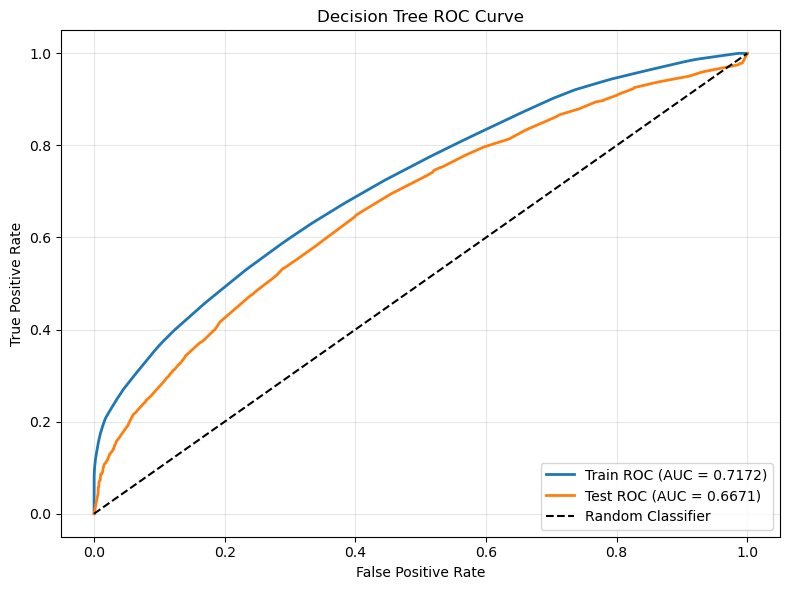

In [106]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from pyspark.ml.functions import vector_to_array

# ============================
# Train ROC
# ============================
train_pdf = train_pred_dt.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

fpr_train, tpr_train, _ = roc_curve(
    train_pdf["label"],
    train_pdf["score"]
)

auc_train = auc(fpr_train, tpr_train)

# ============================
# Test ROC
# ============================
test_pdf = test_pred_dt.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

fpr_test, tpr_test, _ = roc_curve(
    test_pdf["label"],
    test_pdf["score"]
)

auc_test = auc(fpr_test, tpr_test)

# ============================
# Plot ROC Curve
# ============================
plt.figure(figsize=(8,6))

plt.plot(
    fpr_train,
    tpr_train,
    linewidth=2,
    label=f"Train ROC (AUC = {auc_train:.4f})"
)

plt.plot(
    fpr_test,
    tpr_test,
    linewidth=2,
    label=f"Test ROC (AUC = {auc_test:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("decision_tree_roc_curve.png", dpi=300)

plt.show()

In [107]:
from sklearn.metrics import log_loss
from pyspark.ml.functions import vector_to_array

# Train
train_pdf = train_pred_dt.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

train_ll_dt = log_loss(
    train_pdf["label"],
    train_pdf["score"]
)

# Test
test_pdf = test_pred_dt.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

test_ll_dt = log_loss(
    test_pdf["label"],
    test_pdf["score"]
)

print("="*60)
print("Decision Tree LogLoss")
print("="*60)
print(f"Train LogLoss : {train_ll_dt:.4f}")
print(f"Test LogLoss  : {test_ll_dt:.4f}")

Decision Tree LogLoss
Train LogLoss : 0.4243
Test LogLoss  : 0.7708


In [108]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

precision_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

# Train
train_precision_dt = precision_eval.evaluate(train_pred_dt)
train_recall_dt = recall_eval.evaluate(train_pred_dt)
train_f1_dt = f1_eval.evaluate(train_pred_dt)
train_accuracy_dt = accuracy_eval.evaluate(train_pred_dt)

# Test
test_precision_dt = precision_eval.evaluate(test_pred_dt)
test_recall_dt = recall_eval.evaluate(test_pred_dt)
test_f1_dt = f1_eval.evaluate(test_pred_dt)
test_accuracy_dt = accuracy_eval.evaluate(test_pred_dt)

print("="*60)
print("Decision Tree Train Metrics")
print("="*60)
print(f"Accuracy : {train_accuracy_dt:.4f}")
print(f"Precision: {train_precision_dt:.4f}")
print(f"Recall   : {train_recall_dt:.4f}")
print(f"F1 Score : {train_f1_dt:.4f}")

print("\n"+"="*60)
print("Decision Tree Test Metrics")
print("="*60)
print(f"Accuracy : {test_accuracy_dt:.4f}")
print(f"Precision: {test_precision_dt:.4f}")
print(f"Recall   : {test_recall_dt:.4f}")
print(f"F1 Score : {test_f1_dt:.4f}")

Decision Tree Train Metrics
Accuracy : 0.8317
Precision: 0.8208
Recall   : 0.8317
F1 Score : 0.7893

Decision Tree Test Metrics
Accuracy : 0.8081
Precision: 0.7670
Recall   : 0.8081
F1 Score : 0.7611


In [109]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve
from pyspark.ml.functions import vector_to_array

# Train
train_pdf = train_pred_dt.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

fpr, tpr, thresholds = roc_curve(
    train_pdf["label"],
    train_pdf["score"]
)

train_ks = np.max(tpr - fpr)

# Test
test_pdf = test_pred_dt.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

fpr, tpr, thresholds = roc_curve(
    test_pdf["label"],
    test_pdf["score"]
)

test_ks = np.max(tpr - fpr)

print("="*60)
print("Decision Tree KS")
print("="*60)
print(f"Train KS : {train_ks*100:.2f}%")
print(f"Test KS  : {test_ks*100:.2f}%")

Decision Tree KS
Train KS : 29.93%
Test KS  : 24.76%


In [110]:
import pandas as pd
import numpy as np
from pyspark.ml.functions import vector_to_array

pred_pdf = test_pred_dt.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

pred_pdf = pred_pdf.sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

pred_pdf["decile"] = pd.qcut(
    pred_pdf.index,
    10,
    labels=range(1,11)
)

ks_table = pred_pdf.groupby("decile").agg(
    Min_Prob=("score","min"),
    Max_Prob=("score","max"),
    Events=("label","sum"),
    Total=("label","count")
).reset_index()

ks_table["Non_Events"] = ks_table["Total"] - ks_table["Events"]

ks_table["Event_Rate"] = (
    ks_table["Events"] /
    ks_table["Events"].sum() * 100
)

ks_table["Non_Event_Rate"] = (
    ks_table["Non_Events"] /
    ks_table["Non_Events"].sum() * 100
)

ks_table["Cum_Event_Rate"] = ks_table["Event_Rate"].cumsum()
ks_table["Cum_Non_Event_Rate"] = ks_table["Non_Event_Rate"].cumsum()

ks_table["KS"] = (
    ks_table["Cum_Event_Rate"] -
    ks_table["Cum_Non_Event_Rate"]
).abs()

display(ks_table)

ks_table.to_csv(
    "decision_tree_ks_table.csv",
    index=False
)

/tmp/ipykernel_43847/1438927748.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ks_table = pred_pdf.groupby("decile").agg(


,decile,Min_Prob,Max_Prob,Events,Total,Non_Events,Event_Rate,Non_Event_Rate,Cum_Event_Rate,Cum_Non_Event_Rate,KS
0,1,0.305040,1.000000,809,1811,1002,22.853107,6.880450,22.853107,6.880450,15.972657
1,2,0.233740,0.305040,495,1810,1315,13.983051,9.029733,36.836158,15.910183,20.925975
2,3,0.200803,0.233740,429,1810,1381,12.118644,9.482936,48.954802,25.393120,23.561683
3,4,0.174299,0.200803,375,1810,1435,10.593220,9.853739,59.548023,35.246858,24.301164
4,5,0.164023,0.174299,347,1811,1464,9.802260,10.052874,69.350282,45.299732,24.050550
5,6,0.144549,0.164023,277,1810,1533,7.824859,10.526677,77.175141,55.826409,21.348732
6,7,0.134660,0.144549,233,1810,1577,6.581921,10.828813,83.757062,66.655222,17.101840
7,8,0.091340,0.134660,209,1810,1601,5.903955,10.993614,89.661017,77.648836,12.012181
8,9,0.073938,0.091340,167,1810,1643,4.717514,11.282016,94.378531,88.930852,5.447679
9,10,0.000000,0.073938,199,1811,1612,5.621469,11.069148,100.000000,100.000000,0.000000


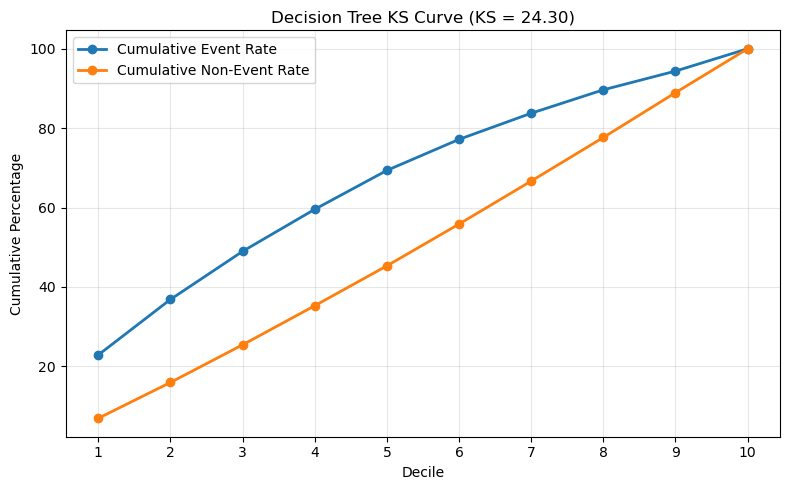

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    ks_table["decile"],
    ks_table["Cum_Event_Rate"],
    marker="o",
    linewidth=2,
    label="Cumulative Event Rate"
)

plt.plot(
    ks_table["decile"],
    ks_table["Cum_Non_Event_Rate"],
    marker="o",
    linewidth=2,
    label="Cumulative Non-Event Rate"
)

plt.title(
    f"Decision Tree KS Curve (KS = {ks_table['KS'].max():.2f})"
)

plt.xlabel("Decile")
plt.ylabel("Cumulative Percentage")

plt.xticks(range(1,11))

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "decision_tree_ks_curve.png",
    dpi=200
)

plt.show()

# Random Forest

In [112]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=6,
    seed=42
)

rf_model = rf.fit(train_model)

26/06/30 21:57:57 WARN DAGScheduler: Broadcasting large task binary with size 1041.7 KiB


In [113]:
train_pred_rf = rf_model.transform(train_model)
test_pred_rf = rf_model.transform(test_model)

In [114]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="probability",
    metricName="areaUnderROC"
)

train_auc_rf = evaluator.evaluate(train_pred_rf)
test_auc_rf = evaluator.evaluate(test_pred_rf)

print("="*60)
print("Random Forest ROC-AUC")
print("="*60)
print(f"Train AUC : {train_auc_rf:.4f}")
print(f"Test AUC  : {test_auc_rf:.4f}")

Random Forest ROC-AUC
Train AUC : 0.6895
Test AUC  : 0.6864


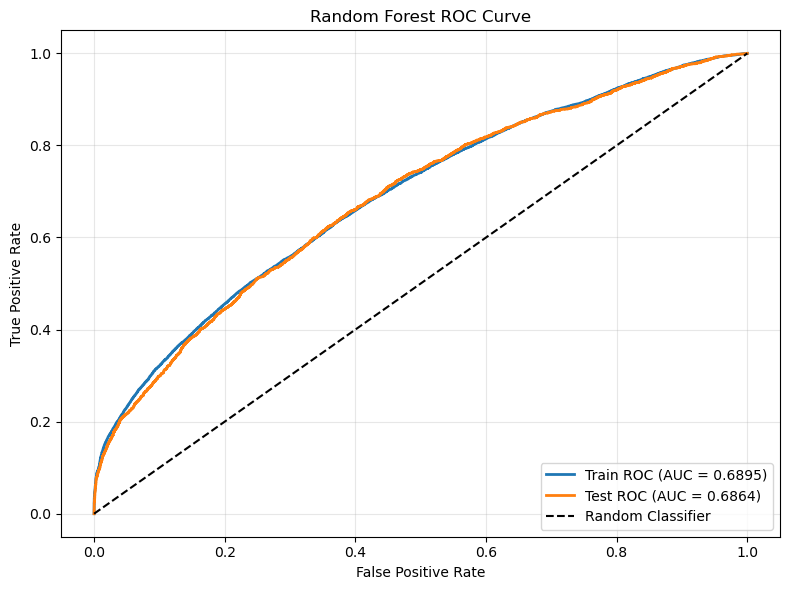

In [115]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from pyspark.ml.functions import vector_to_array

# ============================
# Train ROC
# ============================
train_pdf = train_pred_rf.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

fpr_train, tpr_train, _ = roc_curve(
    train_pdf["label"],
    train_pdf["score"]
)

auc_train = auc(fpr_train, tpr_train)

# ============================
# Test ROC
# ============================
test_pdf = test_pred_rf.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

fpr_test, tpr_test, _ = roc_curve(
    test_pdf["label"],
    test_pdf["score"]
)

auc_test = auc(fpr_test, tpr_test)

# ============================
# Plot ROC Curve
# ============================
plt.figure(figsize=(8,6))

plt.plot(
    fpr_train,
    tpr_train,
    linewidth=2,
    label=f"Train ROC (AUC = {auc_train:.4f})"
)

plt.plot(
    fpr_test,
    tpr_test,
    linewidth=2,
    label=f"Test ROC (AUC = {auc_test:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("random_forest_roc_curve.png", dpi=300)

plt.show()

In [116]:
from sklearn.metrics import log_loss
from pyspark.ml.functions import vector_to_array

# Train
train_pdf = train_pred_rf.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

train_ll_rf = log_loss(
    train_pdf["label"],
    train_pdf["score"]
)

# Test
test_pdf = test_pred_rf.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

test_ll_rf = log_loss(
    test_pdf["label"],
    test_pdf["score"]
)

print("="*60)
print("Random Forest LogLoss")
print("="*60)
print(f"Train LogLoss : {train_ll_rf:.4f}")
print(f"Test LogLoss  : {test_ll_rf:.4f}")

Random Forest LogLoss
Train LogLoss : 0.4515
Test LogLoss  : 0.4553


In [117]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

precision_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

# Train
train_precision_rf = precision_eval.evaluate(train_pred_rf)
train_recall_rf = recall_eval.evaluate(train_pred_rf)
train_f1_rf = f1_eval.evaluate(train_pred_rf)
train_accuracy_rf = accuracy_eval.evaluate(train_pred_rf)

# Test
test_precision_rf = precision_eval.evaluate(test_pred_rf)
test_recall_rf = recall_eval.evaluate(test_pred_rf)
test_f1_rf = f1_eval.evaluate(test_pred_rf)
test_accuracy_rf = accuracy_eval.evaluate(test_pred_rf)

print("="*60)
print("Random Forest Train Metrics")
print("="*60)
print(f"Accuracy : {train_accuracy_rf:.4f}")
print(f"Precision: {train_precision_rf:.4f}")
print(f"Recall   : {train_recall_rf:.4f}")
print(f"F1 Score : {train_f1_rf:.4f}")

print("\n" + "="*60)
print("Random Forest Test Metrics")
print("="*60)
print(f"Accuracy : {test_accuracy_rf:.4f}")
print(f"Precision: {test_precision_rf:.4f}")
print(f"Recall   : {test_recall_rf:.4f}")
print(f"F1 Score : {test_f1_rf:.4f}")

Random Forest Train Metrics
Accuracy : 0.8190
Precision: 0.8090
Recall   : 0.8190
F1 Score : 0.7588

Random Forest Test Metrics
Accuracy : 0.8167
Precision: 0.8017
Recall   : 0.8167
F1 Score : 0.7557


In [118]:
import numpy as np
from sklearn.metrics import roc_curve
from pyspark.ml.functions import vector_to_array

# Train
train_pdf = train_pred_rf.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

fpr, tpr, thresholds = roc_curve(
    train_pdf["label"],
    train_pdf["score"]
)

train_ks_rf = np.max(tpr - fpr)

# Test
test_pdf = test_pred_rf.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

fpr, tpr, thresholds = roc_curve(
    test_pdf["label"],
    test_pdf["score"]
)

test_ks_rf = np.max(tpr - fpr)

print("="*60)
print("Random Forest KS")
print("="*60)
print(f"Train KS : {train_ks_rf*100:.2f}%")
print(f"Test KS  : {test_ks_rf*100:.2f}%")

Random Forest KS
Train KS : 26.26%
Test KS  : 26.52%


In [119]:
import pandas as pd
import numpy as np
from pyspark.ml.functions import vector_to_array

pred_pdf = test_pred_rf.select(
    "label",
    vector_to_array("probability")[1].alias("score")
).toPandas()

pred_pdf = pred_pdf.sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

pred_pdf["decile"] = pd.qcut(
    pred_pdf.index,
    10,
    labels=range(1,11)
)

ks_table = pred_pdf.groupby("decile").agg(
    Min_Prob=("score","min"),
    Max_Prob=("score","max"),
    Events=("label","sum"),
    Total=("label","count")
).reset_index()

ks_table["Non_Events"] = ks_table["Total"] - ks_table["Events"]

ks_table["Event_Rate"] = (
    ks_table["Events"] /
    ks_table["Events"].sum() * 100
)

ks_table["Non_Event_Rate"] = (
    ks_table["Non_Events"] /
    ks_table["Non_Events"].sum() * 100
)

ks_table["Cum_Event_Rate"] = ks_table["Event_Rate"].cumsum()
ks_table["Cum_Non_Event_Rate"] = ks_table["Non_Event_Rate"].cumsum()

ks_table["KS"] = (
    ks_table["Cum_Event_Rate"] -
    ks_table["Cum_Non_Event_Rate"]
).abs()

display(ks_table)

ks_table.to_csv(
    "random_forest_ks_table.csv",
    index=False
)

/tmp/ipykernel_43847/1642870281.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ks_table = pred_pdf.groupby("decile").agg(


,decile,Min_Prob,Max_Prob,Events,Total,Non_Events,Event_Rate,Non_Event_Rate,Cum_Event_Rate,Cum_Non_Event_Rate,KS
0,1,0.254119,0.902794,859,1811,952,24.265537,6.537115,24.265537,6.537115,1.772842e+01
1,2,0.203693,0.254118,510,1810,1300,14.406780,8.926732,38.672316,15.463847,2.320847e+01
2,3,0.191617,0.203689,436,1810,1374,12.316384,9.434869,50.988701,24.898716,2.608998e+01
3,4,0.182121,0.191617,362,1810,1448,10.225989,9.943006,61.214689,34.841722,2.637297e+01
4,5,0.171550,0.182121,343,1811,1468,9.689266,10.080341,70.903955,44.922063,2.598189e+01
5,6,0.163057,0.171549,282,1810,1528,7.966102,10.492344,78.870056,55.414406,2.345565e+01
6,7,0.155748,0.163057,235,1810,1575,6.638418,10.815079,85.508475,66.229486,1.927899e+01
7,8,0.145278,0.155741,181,1810,1629,5.112994,11.185882,90.621469,77.415368,1.320610e+01
8,9,0.129368,0.145264,211,1810,1599,5.960452,10.979881,96.581921,88.395248,8.186673e+00
9,10,0.118852,0.129359,121,1811,1690,3.418079,11.604752,100.000000,100.000000,1.421085e-14


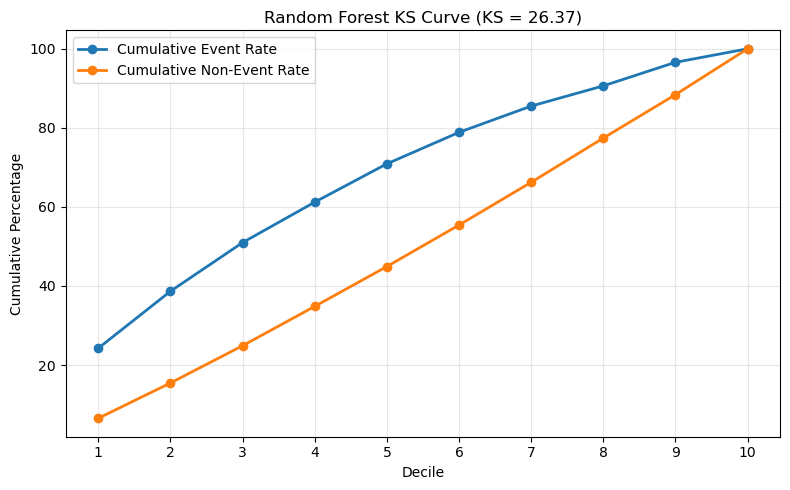

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    ks_table["decile"],
    ks_table["Cum_Event_Rate"],
    marker="o",
    linewidth=2,
    label="Cumulative Event Rate"
)

plt.plot(
    ks_table["decile"],
    ks_table["Cum_Non_Event_Rate"],
    marker="o",
    linewidth=2,
    label="Cumulative Non-Event Rate"
)

plt.title(
    f"Random Forest KS Curve (KS = {ks_table['KS'].max():.2f})"
)

plt.xlabel("Decile")
plt.ylabel("Cumulative Percentage")

plt.xticks(range(1,11))

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "random_forest_ks_curve.png",
    dpi=200
)

plt.show()

In [121]:
oot_df.show(1)

+---+-------------+--------------+---------------+------------+-----------------+-----------------+-----------------+------------------+---------------+---------------+---------------+--------------------+--------------------+--------------------+--------------------+---------------------+---------------+--------------------+--------------------+--------------------+---------------------+----------------+------------------+-----------------------+-----------------------+-----------------------+------------------------+------------------------+-----------------------+-----------------------------+-----------------------------------+-------------+----------------+----------------+----------------+----------------+----------------+----------------+--------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+----------------------+----------+----------+-----+-----+-----+-----+-----+-----+---

In [122]:
len(oot_df.columns)

235

In [123]:
print(oot_df.columns)

['id', 'FIRST_PRODUCT', 'LATEST_PRODUCT', 'MAX_BUR_VINTAGE', 'TOTAL_TRADES', 'TOTAL_TRADES_1_MN', 'TOTAL_TRADES_3_MN', 'TOTAL_TRADES_6_MN', 'TOTAL_TRADES_12_MN', 'TOTAL_HL_TRADES', 'TOTAL_GL_TRADES', 'TOTAL_PL_TRADES', 'TOTAL_LIVE_PL_TRADES', 'TOTAL_PL_TRADES_1_MN', 'TOTAL_PL_TRADES_3_MN', 'TOTAL_PL_TRADES_6_MN', 'TOTAL_PL_TRADES_12_MN', 'TOTAL_CC_TRADES', 'TOTAL_CC_TRADES_1_MN', 'TOTAL_CC_TRADES_3_MN', 'TOTAL_CC_TRADES_6_MN', 'TOTAL_CC_TRADES_12_MN', 'TOTAL_SEC_TRADES', 'TOTAL_UNSEC_TRADES', 'TOTAL_UNSEC_TRADES_1_MN', 'TOTAL_UNSEC_TRADES_3_MN', 'TOTAL_UNSEC_TRADES_6_MN', 'TOTAL_UNSEC_TRADES_12_MN', 'TOTAL_INSTALLMENT_TRADES', 'TOTAL_LIVE_TRADES_M0_M2', 'TOTAL_LIVE_UNSEC_TRADES_M0_M2', 'TOTAL_LIVE_INSTALLMENT_TRADES_M0_M2', 'TOTAL_BALANCE', 'TOTAL_PL_BALANCE', 'TOTAL_BL_BALANCE', 'TOTAL_CD_BALANCE', 'TOTAL_AL_BALANCE', 'TOTAL_HL_BALANCE', 'TOTAL_CC_BALANCE', 'TOTAL_SANC_AMT', 'TOTAL_PL_SANC_AMT', 'TOTAL_BL_SANC_AMT', 'TOTAL_CD_SANC_AMT', 'TOTAL_AL_SANC_AMT', 'TOTAL_HL_SANC_AMT', 'TOTAL

In [124]:
print(final_features)

['H1203', 'H0103', 'H4303', 'H4203', 'H3203', 'H1212', 'H4212', 'H0112', 'H3212', 'H4112', 'DPD_RECOVERY_RATE', 'H4236', 'H4336', 'H0236', 'MICRO_UTIL', 'MEDIAN_DAYS_SO_UNSECURED_IN_LAST_36_MN', 'TOTAL_WO_SF_36O_TRADES', 'MACRO_UTIL', 'MEDIAN_DAYS_SO_IN_LAST_36_MN', 'TOTAL_WO_SF_TRADES', 'MEDIAN_DAYS_SO_PL_IN_LAST_36_MN', 'MEDIAN_DAYS_SO_UNSECURED_IN_LAST_12_MN', 'NUM_CONSEC_MONTHS_ZERO_DPD', 'TOTAL_CC_TRADES', 'TOTAL_PL_TRADES_6_MN', 'DPD_SLOPE_6M', 'TOTAL_CC_SANC_AMT', 'MEDIAN_DAYS_SO_UNSECURED_IN_LAST_6_MN', 'MEDIAN_DAYS_SO_PL_IN_LAST_12_MN', 'AVG_PL_BUR_VINTAGE', 'TOTAL_PL_SANC_AMT', 'MEDIAN_DAYS_SO_PL_IN_LAST_6_MN', 'G403', 'AVG_CC_BUR_VINTAGE', 'G7112', 'LATEST_PRODUCT', 'G412']


In [125]:
# Rename user_id to id
oot_df = oot_df.withColumnRenamed("user_id", "id")

In [126]:
# Keep only the selected features
oot_final = oot_df.select(
    ["id"] + final_features
)

In [127]:
len(oot_final.columns)

38

In [128]:
# Apply the fitted One-Hot Encoding pipeline
oot_final = ohe_model.transform(oot_final)

In [129]:
# Create the features column
oot_final = assembler.transform(oot_final)

In [130]:
oot_final.select("id", "features").show(5, truncate=False)

+---+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|id |features                                                                                                                                                                                                                             |
+---+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|7  |(52,[1,7,9,10,14,15,17,18,20,21,22,25,27,28,29,30,31,32,33,35,36],[1.0,1.0,2.0,1.0,-1.0,11.0,-1.0,15.0,15.0,27.0,25.0,-1.0,-1.0,27.0,22.01707779882353,450932.0,-1.0,1.0,-1.0,9.0,1.0])                                              |
|22 |(52,[3,10,14,15,17,18,20,21,22,23,25,26,27,28,29,30

# Predict using the trained XGBoost model

In [131]:
oot_pred = xgb_model.transform(oot_final)

In [132]:
# Create the submission DataFrame

from pyspark.ml.functions import vector_to_array

submission = oot_pred.select(
    "id",
    vector_to_array("probability")[0].alias("y_pred_0"),
    vector_to_array("probability")[1].alias("y_pred_1")
)

In [142]:
submission.show()

2026-06-30 22:02:30,970 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


+------------+------------------+-------------------+
|          id|          y_pred_0|           y_pred_1|
+------------+------------------+-------------------+
| 60129556744|0.7711389064788818|0.22886107861995697|
| 34359738920| 0.656002938747406|  0.343997061252594|
|120259084395|0.7074190378189087| 0.2925809919834137|
|        6613|0.5741734504699707| 0.4258265793323517|
|  8589943638|0.5941133499145508|0.40588662028312683|
| 25769817960| 0.933241069316864|0.06675893813371658|
| 17179870642|0.4959542751312256| 0.5040457248687744|
| 60129555251|0.6687004566192627| 0.3312995433807373|
| 60129554534|0.6110901832580566|0.38890978693962097|
| 42949687128|0.8788002133369446|0.12119976431131363|
| 25769804572|0.7184343338012695|0.28156566619873047|
| 60129545284|0.7808937430381775| 0.2191062718629837|
| 51539611685|   0.7355996966362|0.26440030336380005|
| 51539620420|0.7661596536636353|0.23384031653404236|
| 42949684991|0.6420955061912537|0.35790449380874634|
| 25769814850|0.827398478984

In [136]:
case_study_users = spark.read.csv("case_study_submission_users_oot.csv", header=True, inferSchema=True)

In [139]:
case_study_users = case_study_users.withColumnRenamed("user_id", "id")

In [140]:
submission = (
    case_study_users
    .join(submission, on="id", how="left")
)

In [141]:
case_study_users.count()

39962

In [143]:
submission_pd = submission.toPandas()

2026-06-30 22:02:39,251 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


In [144]:
submission_pd.isna().sum()

id          0
y_pred_0    0
y_pred_1    0
dtype: int64